<a href="https://colab.research.google.com/github/itsdiego1012-source/Assignments/blob/PDI---Assignments/Pr%C3%A1ctica%208.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 8:**
**Equipo 6:**
*   Castillo Díaz Ulises 	            2050354
*   González Garza Jorge Alberto	    2043501
*   Muñoz Baca Axel	                  2132103
*   Rodríguez Arreguín Diego Eduardo 	2004407

# **PARTE 1**

**Carga de librerías utilizadas**

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Carga de imágen**

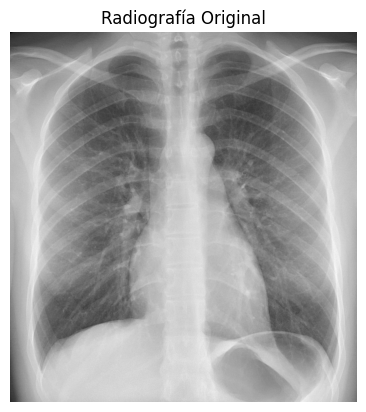

In [19]:
# Cargar la imagen médica original
img_org = 'XRAY.jpg'
img = cv.imread(img_org, cv.IMREAD_GRAYSCALE)

# Mostrar imagen en escala de grises
plt.imshow(img, cmap='gray')
plt.title('Radiografía Original')
plt.axis('off')
plt.show()

# **Ejercicio 1:** *Filtros de Suavizado*

In [20]:
# 1. Filtro de Media (Kernel 3x3) -> Suavizado ligero
blur_media = cv.blur(img, (3, 3))

# 2. Filtro Gaussiano (Kernel 5x5) -> Reducción de ruido gaussiano
blur_gauss = cv.GaussianBlur(img, (5, 5), 0)

# 3. Filtro de Mediana (Kernel 11x11) -> Suavizado agresivo (pérdida de textura fina)
blur_median = cv.medianBlur(img, 11)

**Comparación de filtros de suavizado**

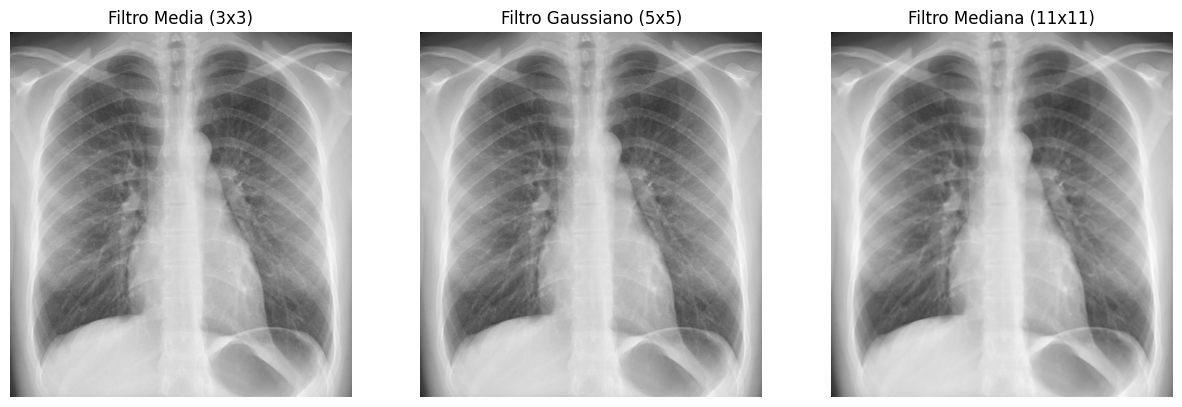

In [21]:
# Visualización de filtros de suavizado
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(blur_media, cmap='gray')
plt.title('Filtro Media (3x3)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blur_gauss, cmap='gray')
plt.title('Filtro Gaussiano (5x5)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blur_median, cmap='gray')
plt.title('Filtro Mediana (11x11)')
plt.axis('off')

plt.show()

## **Ejercicio 2:** *Detección de Bordes*

In [22]:
# 1. Sobel en X y Y
sobelx = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
# Combinar magnitud
sobel_combined = cv.magnitude(sobelx, sobely)

# 2. Laplaciano
laplacian = cv.Laplacian(img, cv.CV_64F, None, 5)
laplacian_abs = cv.convertScaleAbs(laplacian)

# 3. Filtro Kirsch (Dirección Norte - Manual)
# Máscara para detectar bordes horizontales superiores
kernel_kirsch_n = np.array([[ 5,  5,  5],
                            [-3,  0, -3],
                            [-3, -3, -3]])

kirsch_n = cv.filter2D(img, -1, kernel_kirsch_n)

**Comparación de filtros de detección de bordes**

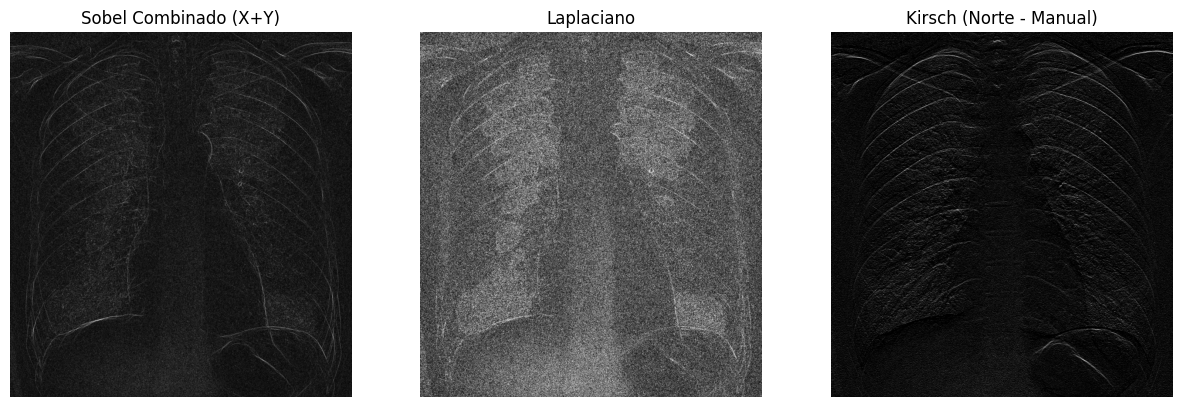

In [23]:
# Visualización de detección de bordes
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combinado (X+Y)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(kirsch_n, cmap='gray')
plt.title('Kirsch (Norte - Manual)')
plt.axis('off')

plt.show()

# **Ejercicio 3:** *Máscara Personalizada (Realce)*

In [24]:
# Máscara de afilado (Sharpening) para aumento de contraste en bordes locales
kernel_custom = np.array([[ 1, -5,  1],
                          [-5,  17, -5],
                          [ 1, -5,  1]])

img_custom = cv.filter2D(img, -1, kernel_custom)

**Comparación de realce con imágen original**

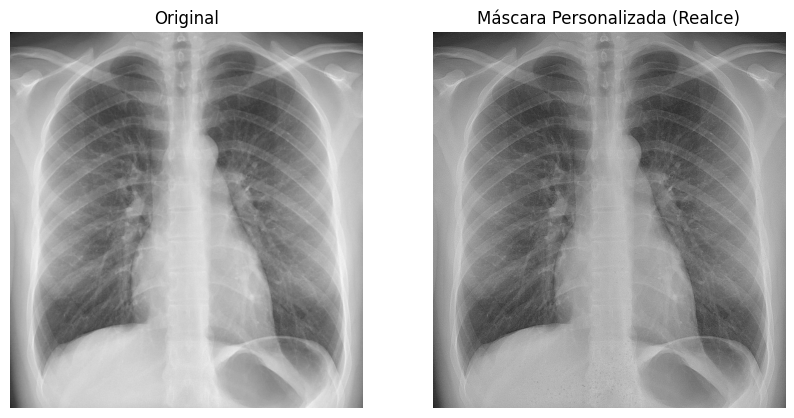

In [25]:
# Comparación con imagen original
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_custom, cmap='gray')
plt.title('Máscara Personalizada (Realce)')
plt.axis('off')

plt.show()

# **PARTE 2**

In [26]:
# Función auxiliar para aplicar filtro en frecuencia
def aplicar_filtro_frecuencia(img, tipo='bajas', radio=30):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Crear máscara
    mask = np.zeros((rows, cols, 2), np.uint8)
    centro = [crow, ccol]
    x, y = np.ogrid[:rows, :cols]
    mask_area = (x - centro[0]) ** 2 + (y - centro[1]) ** 2 <= radio*radio

    if tipo == 'bajas':
        mask[mask_area] = 1
    elif tipo == 'altas':
        mask = np.ones((rows, cols, 2), np.uint8)
        mask[mask_area] = 0

    # Transformada de Fourier (DFT)
    dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Aplicar máscara
    fshift = dft_shift * mask

    # Transformada Inversa (IDFT)
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv.idft(f_ishift)
    img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])

    # Normalizar para visualizar
    cv.normalize(img_back, img_back, 0, 255, cv.NORM_MINMAX)
    return img_back, mask[:,:,0] * 255

**Carga de imagen**

In [27]:
# Cargar imagen CTS
img_cts = cv.imread('CTS.jpg', cv.IMREAD_GRAYSCALE)

**Aplicación de filtros Pasa Bajas**

In [28]:
# Aplicar Filtros Pasa Bajas con diferentes radios
img_lp_20, mask_20 = aplicar_filtro_frecuencia(img_cts, 'bajas', 20)
img_lp_50, mask_50 = aplicar_filtro_frecuencia(img_cts, 'bajas', 50)
img_lp_80, mask_80 = aplicar_filtro_frecuencia(img_cts, 'bajas', 80)

**Comparación entre original y filtros pasa bajas**

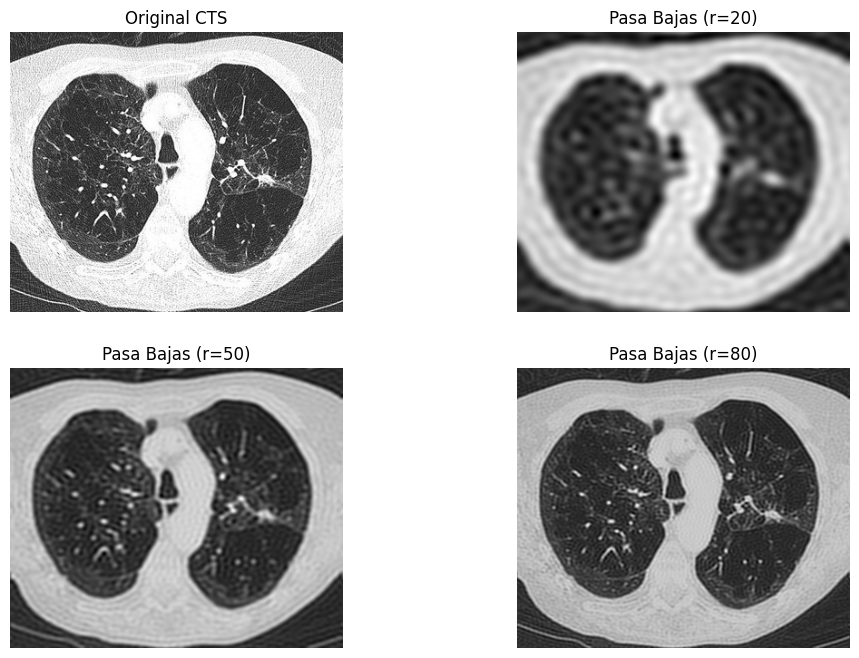

In [29]:
# Mostrar resultados
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img_cts, cmap='gray'); plt.title('Original CTS'); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(img_lp_20, cmap='gray'); plt.title('Pasa Bajas (r=20)'); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(img_lp_50, cmap='gray'); plt.title('Pasa Bajas (r=50)'); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(img_lp_80, cmap='gray'); plt.title('Pasa Bajas (r=80)'); plt.axis('off')
plt.show()

**Ejercicio:** *Filtros Pasa Altas y Configuraciones*

In [30]:
# 1. Pasa Altas Estándar (r=30)
img_hp_30, mask_hp = aplicar_filtro_frecuencia(img_cts, 'altas', 30)

# 2. Configuración de Anillo (Band-Pass) - Manual
rows, cols = img_cts.shape
crow, ccol = rows // 2, cols // 2
mask_anillo = np.zeros((rows, cols, 2), np.uint8)
x, y = np.ogrid[:rows, :cols]

# Anillo entre radio 30 y 80
mask_area_outer = (x - crow)**2 + (y - ccol)**2 <= 80*80
mask_area_inner = (x - crow)**2 + (y - ccol)**2 <= 30*30
mask_anillo[mask_area_outer ^ mask_area_inner] = 1

# Aplicar filtro anillo
dft = cv.dft(np.float32(img_cts), flags=cv.DFT_COMPLEX_OUTPUT)
fshift = np.fft.fftshift(dft) * mask_anillo
f_ishift = np.fft.ifftshift(fshift)
img_back_anillo = cv.magnitude(cv.idft(f_ishift)[:,:,0], cv.idft(f_ishift)[:,:,1])
cv.normalize(img_back_anillo, img_back_anillo, 0, 255, cv.NORM_MINMAX)

array([[13.887407  , 16.823608  , 17.336777  , ...,  7.6919336 ,
         2.613968  ,  6.579532  ],
       [ 9.885967  , 12.237303  , 10.689755  , ...,  7.412158  ,
         5.1975613 ,  2.697377  ],
       [13.171477  , 11.277841  ,  4.441718  , ...,  8.972773  ,
         1.12721   ,  8.12298   ],
       ...,
       [ 2.7143328 ,  3.1377864 ,  2.9499147 , ...,  5.5233073 ,
         0.32561323,  0.19163497],
       [19.134941  , 17.743488  , 17.726501  , ..., 14.102977  ,
         4.3032284 , 16.24504   ],
       [23.541151  , 23.533754  , 21.919815  , ..., 12.563278  ,
         3.595614  , 17.332634  ]], dtype=float32)

**Comparación entre original y filtros pasa altas**

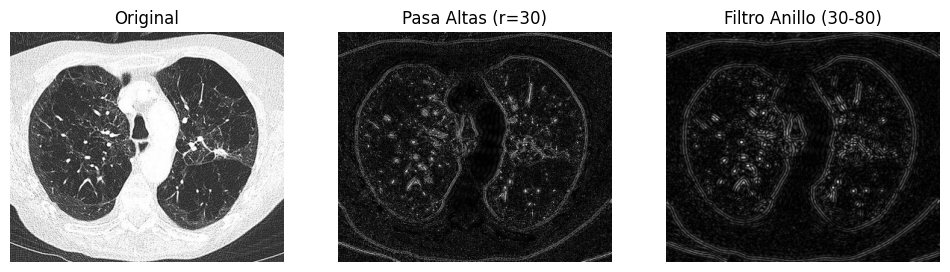

In [31]:
# Visualización
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img_cts, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(img_hp_30, cmap='gray'); plt.title('Pasa Altas (r=30)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(img_back_anillo, cmap='gray'); plt.title('Filtro Anillo (30-80)'); plt.axis('off')
plt.show()

**Carga de imagenes adicionales**

In [32]:
# Cargar imágenes adicionales
img_mri = cv.imread('MRI.jpg', cv.IMREAD_GRAYSCALE)
img_tem = cv.imread('TEM.jpg', cv.IMREAD_GRAYSCALE)

**Procesamiento a imágenes adicionales**

In [33]:

# MRI: Suavizado para reducir ruido granulado (Pasa Bajas r=40)
img_mri_lp, _ = aplicar_filtro_frecuencia(img_mri, 'bajas', 40)

# TEM: Realce de bordes para ver membranas (Pasa Altas r=20)
img_tem_hp, _ = aplicar_filtro_frecuencia(img_tem, 'altas', 20)

**Comparación entre imágenes y su tranformada inversa**

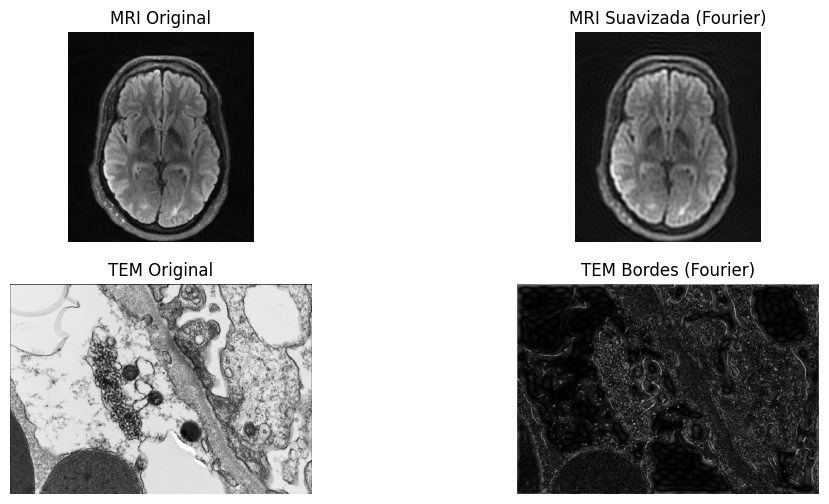

In [34]:
# Mostrar
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.imshow(img_mri, cmap='gray'); plt.title('MRI Original'); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(img_mri_lp, cmap='gray'); plt.title('MRI Suavizada (Fourier)'); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(img_tem, cmap='gray'); plt.title('TEM Original'); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(img_tem_hp, cmap='gray'); plt.title('TEM Bordes (Fourier)'); plt.axis('off')
plt.show()